Contours to describe the flow field evolution with time.

In the thesis I will have 3, 3 $\times$ 3 contour plots for non-rotating, medium rotation, high rotation with times showing formation, translation, and decay.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
# dirPath = "C:/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)


####Import Ollie Tools MAC
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()
print(plt.rcParams["figure.dpi"])


# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5')

vels = h5file['Narrow']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
vort, vort_gauss = oj.calculate_vorticity(u, v)
h5file.close()

/Users/olliejackson/Coding
Thesis plot settings applied
400.0


Create 3 $\times$ 3 plot

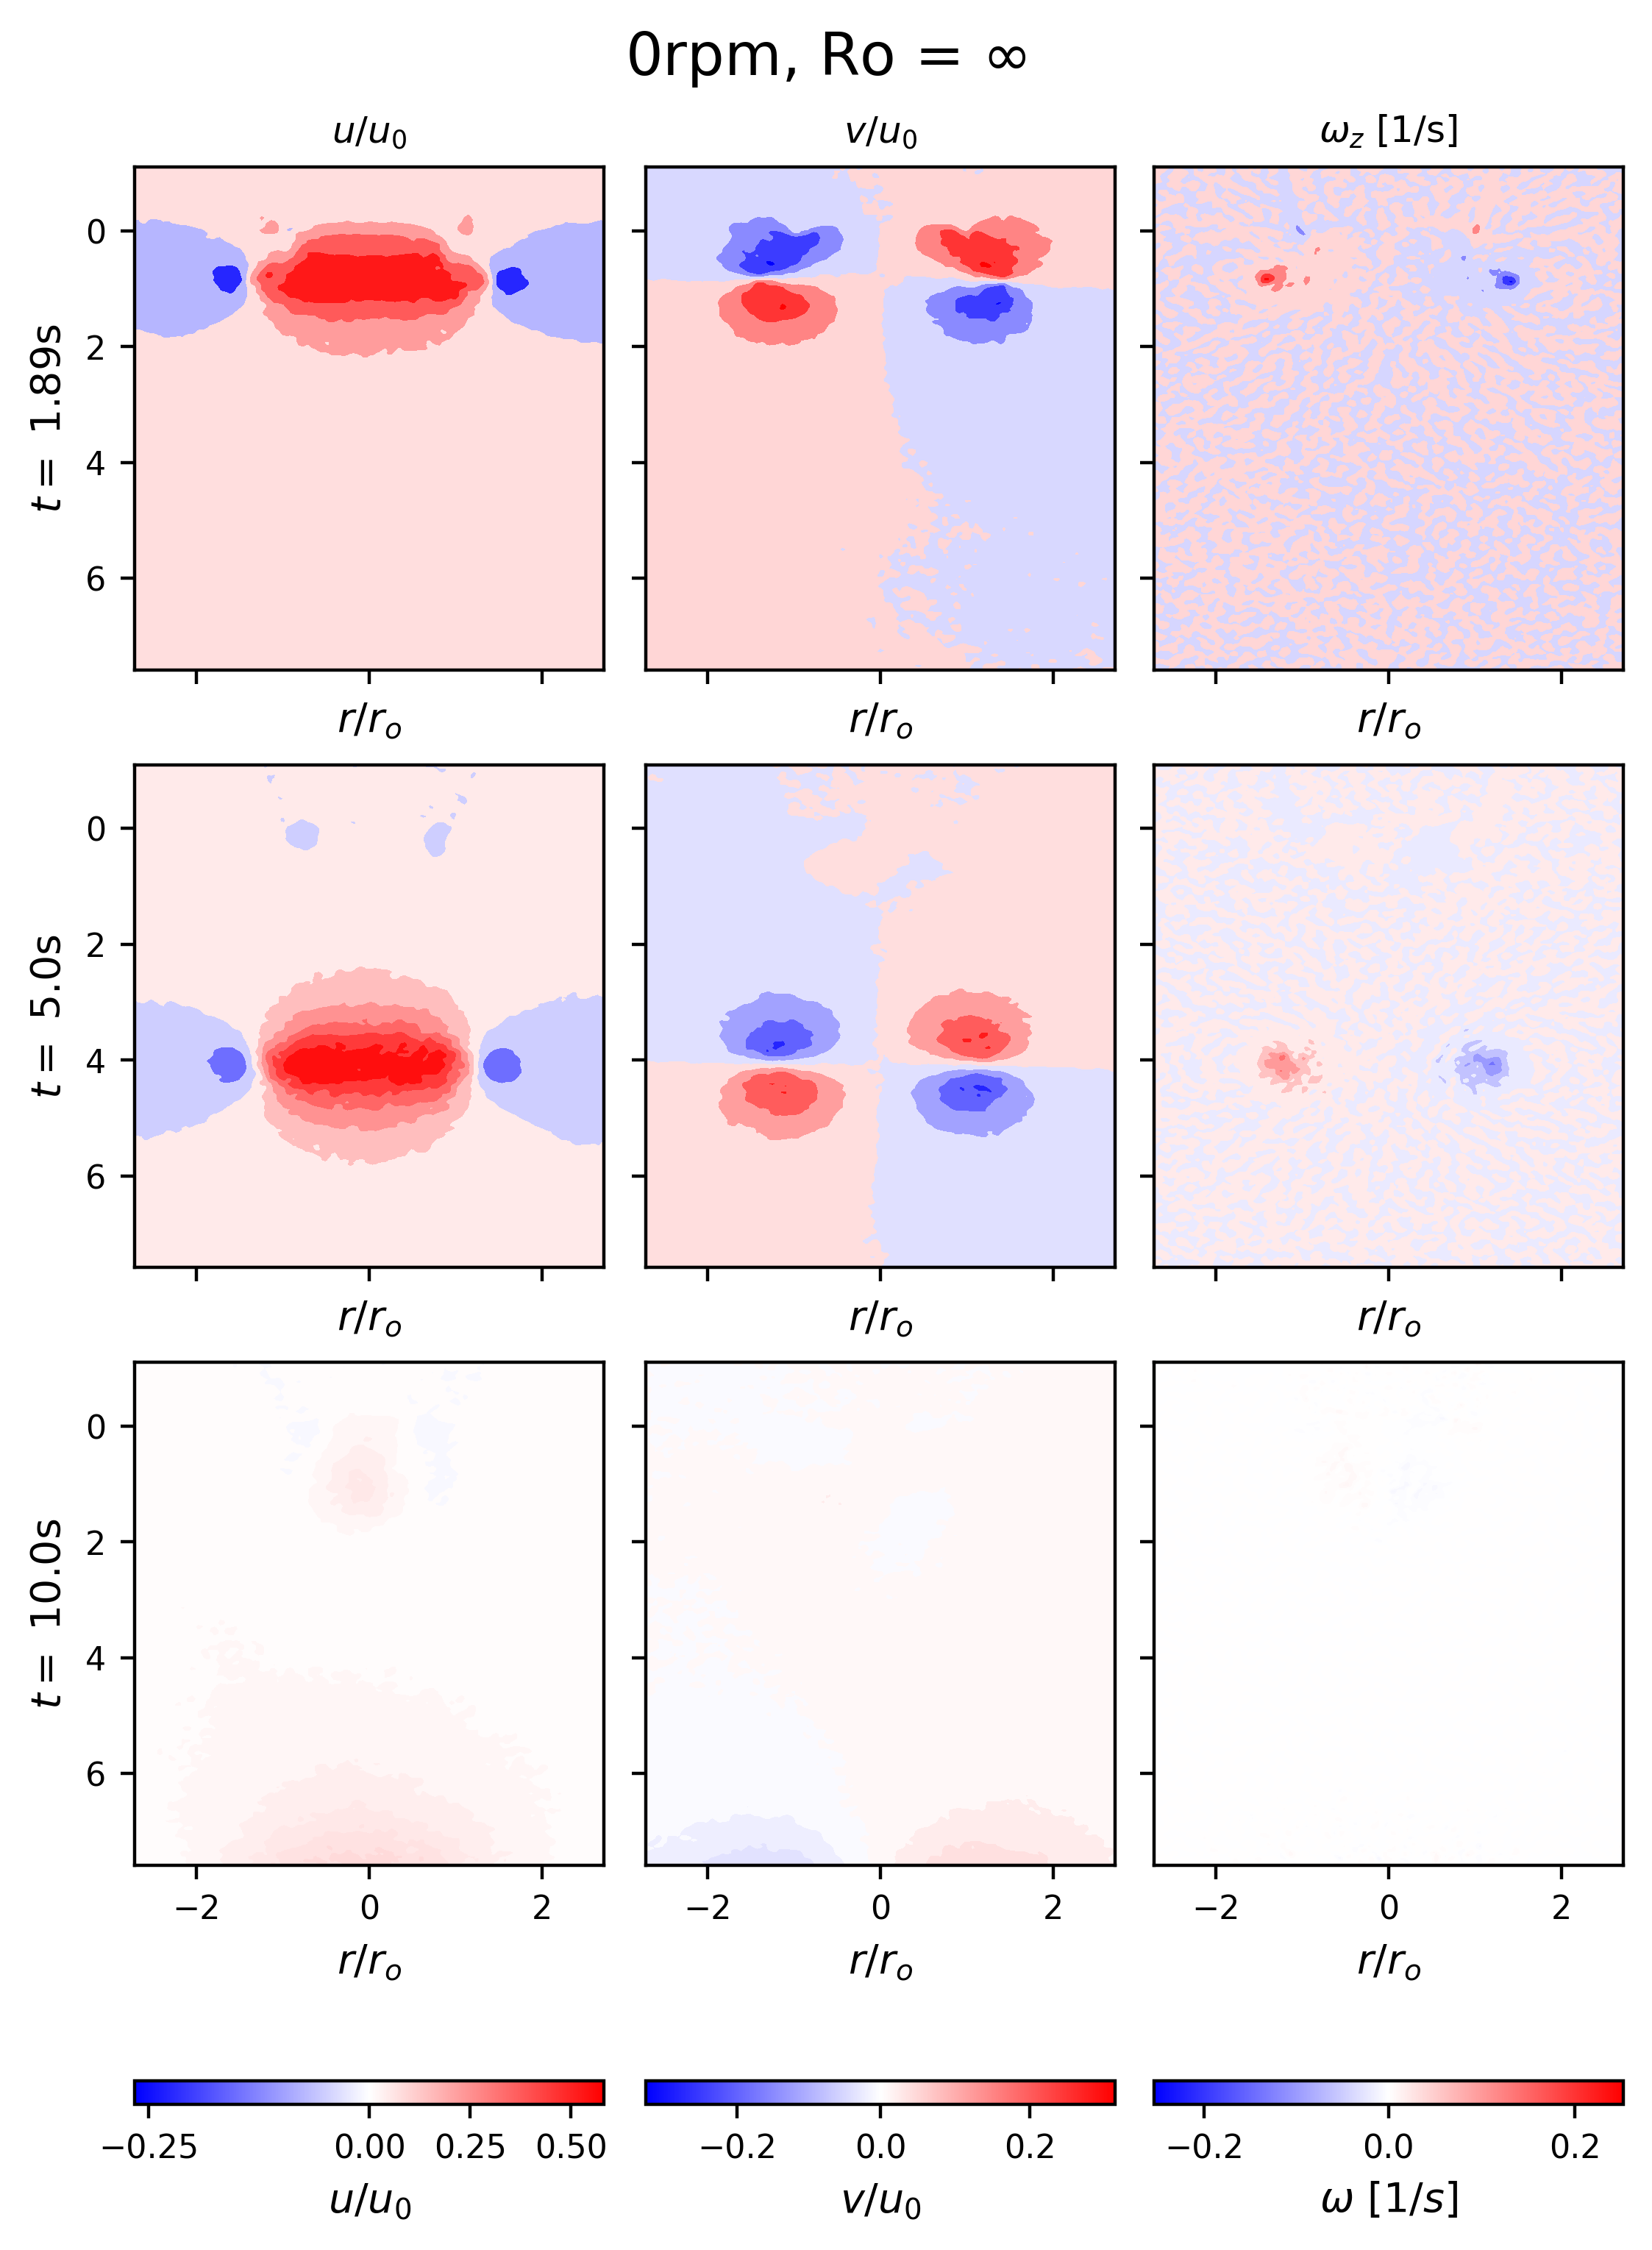

In [10]:
index = 0

frame1 = 170
frame2 = 450
frame3 = 900
frames = [frame1, frame2, frame3]

#set the normalisation for the colourmap
#choose the frames
#plot the data
#frame 80 is the start of injection = 0.888s 
#frame 170 would be 1 second after injection starts

umin = min(np.min(u[frame1,:,:]), np.min(u[frame2,:,:]), np.min(u[frame3,:,:]))
umax = max(np.max(u[frame1,:,:]), np.max(u[frame2,:,:]), np.max(u[frame3,:,:]))
unorm = colors.TwoSlopeNorm(vmin=umin, vcenter=0, vmax=umax)

vmin = min(np.min(v[frame1,:,:]), np.min(v[frame2,:,:]), np.min(v[frame3,:,:]))
vmax = max(np.max(v[frame1,:,:]), np.max(v[frame2,:,:]), np.max(v[frame3,:,:]))
vnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

omin = min(np.min(vort[frame1,:,:]), np.min(vort[frame2,:,:]), np.min(vort[frame3,:,:]))
omax = max(np.max(vort[frame1,:,:]), np.max(vort[frame2,:,:]), np.max(vort[frame3,:,:]))
onorm = colors.TwoSlopeNorm(vmin=omin, vcenter=0, vmax=omax)

f2, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
# f2.suptitle(r'12rpm, Ek = $8.5e-07$ ')
f2.suptitle(rf'0rpm, Ro = {oj.Ro(0.1, 0)}')
for i in range(3):
    ax[0, 0].set_title(r'$u/u_{0}$', fontsize=9)
    ax[0, 1].set_title(r'$v/u_{0}$', fontsize=9)
    ax[0, 2].set_title(r'$\omega_{z}$ [1/s]', fontsize=9)


    for frame in frames:
        ax[i, 0].set_ylim(z_nd.max(), z_nd.min())
        im0 = ax[i, 0].contourf(r_nd, z_nd, np.rot90(u[frames[index],:,:], 3), cmap = 'bwr', norm=unorm)
        ax[i, 0].set_xlabel(r"$r/r_{o}$")
        ax[i, 0].set_ylabel(rf"$t =$ {round(frames[index]/90, 2)}s")
        im1 = ax[i, 1].contourf(r_nd, z_nd, np.rot90(v[frames[index],:,:], 3), cmap = 'bwr', norm=vnorm)
        ax[i, 1].set_xlabel(r"$r/r_{o}$")
        im2 =ax[i, 2].contourf(r_nd, z_nd, np.rot90(vort[frames[index],:,:],3), cmap = 'bwr', norm=onorm)
        # ax[i, 2].legend(prop={'size': 8})
        ax[i, 2].set_xlabel(r"$r/r_{o}$")
    index += 1

f2.colorbar(matplotlib.cm.ScalarMappable(norm=unorm, cmap='bwr'), ax=ax[:,0], label=r'$u/u_{0}$', location='bottom')
f2.colorbar(matplotlib.cm.ScalarMappable(norm=vnorm, cmap='bwr'), ax=ax[:,1], label=r'$v/u_{0}$', location='bottom')
f2.colorbar(matplotlib.cm.ScalarMappable(norm=onorm, cmap='bwr'), ax=ax[:,2], label=r'$\omega ~[1/s]$', location='bottom')

# cbar0 = f2.colorbar(im0, ax=ax[:,0], label=r'$u/u_{0}$', location='bottom')
# cbar1 = f2.colorbar(im1, ax=ax[:,1], label=r'$v/u_{0}$', location='bottom')
# cbar2 = f2.colorbar(im2, ax=ax[:,2], label=r'$\omega ~[1/s]$', location='bottom')

# cbar0.ax.locator_params(nbins=5)
# cbar1.ax.locator_params(nbins=5)
# cbar2.ax.locator_params(nbins=5)

plt.show()